In [1]:
import os
import json
import joblib
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import shap

from pathlib import Path

from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    precision_score,
    recall_score,
    f1_score,
    average_precision_score,
    precision_recall_curve
)

from sklearn.model_selection import (
    StratifiedKFold,
    GridSearchCV,
    cross_validate
)

from sklearn.ensemble import VotingClassifier
!pip install lightgbm

from xgboost import XGBClassifier
from lightgbm import LGBMClassifier

Defaulting to user installation because normal site-packages is not writeable


In [2]:
ARTIFACTS_DIR = Path("artifacts")
RESULTS_DIR = Path("results")
SHAP_DIR = RESULTS_DIR / "shap"

RESULTS_DIR.mkdir(exist_ok=True)
SHAP_DIR.mkdir(parents=True, exist_ok=True)

In [3]:
X_train = np.load(ARTIFACTS_DIR / "X_train.npy")
X_val = np.load(ARTIFACTS_DIR / "X_val.npy")

y_train = np.load(ARTIFACTS_DIR / "y_train.npy")
y_val = np.load(ARTIFACTS_DIR / "y_val.npy")

feature_columns = joblib.load(
    ARTIFACTS_DIR / "feature_columns.pkl"
)

print("X_train shape:", X_train.shape)
print("X_val shape:", X_val.shape)

X_train shape: (3200, 28)
X_val shape: (800, 28)


In [4]:
fraud_rate_train = np.mean(y_train)

print("Fraud Rate:", fraud_rate_train)

Fraud Rate: 0.1715625


In [5]:
neg = np.sum(y_train == 0)
pos = np.sum(y_train == 1)

scale_pos_weight = neg / pos

print("Negative samples:", neg)
print("Positive samples:", pos)
print("scale_pos_weight:", scale_pos_weight)

Negative samples: 2651
Positive samples: 549
scale_pos_weight: 4.828779599271402


In [6]:
def evaluate_model(y_true, y_prob, threshold=0.5):

    y_pred = (y_prob >= threshold).astype(int)

    precision = precision_score(y_true, y_pred)
    recall = recall_score(y_true, y_pred)
    f1 = f1_score(y_true, y_pred)

    pr_auc = average_precision_score(y_true, y_prob)

    return {
        "Precision": precision,
        "Recall": recall,
        "F1": f1,
        "PR_AUC": pr_auc
    }

In [7]:
cv = StratifiedKFold(
    n_splits=5,
    shuffle=True,
    random_state=42
)

In [8]:
log_reg = LogisticRegression(
    class_weight='balanced',
    random_state=42,
    max_iter=1000
)

In [9]:
log_cv_results = cross_validate(
    log_reg,
    X_train,
    y_train,
    cv=cv,
    scoring={
        "precision": "precision",
        "recall": "recall",
        "f1": "f1",
        "pr_auc": "average_precision"
    },
    n_jobs=-1
)

print("Average PR-AUC:",
      log_cv_results['test_pr_auc'].mean())

Average PR-AUC: 0.3485652745602758


In [10]:
log_reg.fit(X_train, y_train)

LogisticRegression(class_weight='balanced', max_iter=1000, random_state=42)

In [11]:
log_val_prob = log_reg.predict_proba(X_val)[:, 1]

In [12]:
baseline_metrics = evaluate_model(
    y_val,
    log_val_prob
)

baseline_metrics

{'Precision': 0.275,
 'Recall': 0.6423357664233577,
 'F1': 0.3851203501094092,
 'PR_AUC': np.float64(0.34521012358651226)}

In [13]:
with open(RESULTS_DIR / "baseline_metrics.json", "w") as f:
    json.dump(baseline_metrics, f, indent=2)

In [14]:
xgb_model = XGBClassifier(
    objective='binary:logistic',
    eval_metric='logloss',
    random_state=42,
    scale_pos_weight=scale_pos_weight,
    tree_method='hist'
)

In [15]:
param_grid = {
    "max_depth": [3, 5, 7],
    "learning_rate": [0.01, 0.1],
    "subsample": [0.8, 1.0]
}

In [16]:
xgb_grid = GridSearchCV(
    estimator=xgb_model,
    param_grid=param_grid,
    scoring='average_precision',
    cv=cv,
    n_jobs=-1,
    verbose=1
)

In [17]:
xgb_grid.fit(X_train, y_train)

Fitting 5 folds for each of 12 candidates, totalling 60 fits


GridSearchCV(cv=StratifiedKFold(n_splits=5, random_state=42, shuffle=True),
             estimator=XGBClassifier(base_score=None, booster=None,
                                     callbacks=None, colsample_bylevel=None,
                                     colsample_bynode=None,
                                     colsample_bytree=None, device=None,
                                     early_stopping_rounds=None,
                                     enable_categorical=False,
                                     eval_metric='logloss', feature_types=None,
                                     feature_weights=None, gamma=None,
                                     grow_...
                                     max_cat_threshold=None,
                                     max_cat_to_onehot=None,
                                     max_delta_step=None, max_depth=None,
                                     max_leaves=None, min_child_weight=None,
                                     missing=nan, monotone_constraints=None,
                                     multi_strategy=None, n_estimators=None,
                                     n_jobs=None, num_parallel_tree=None, ...),
             n_jobs=-1,
             param_grid={'learning_rate': [0.01, 0.1], 'max_depth': [3, 5, 7],
                         'subsample': [0.8, 1.0]},
             scoring='average_precision', verbose=1)

In [18]:
best_xgb = xgb_grid.best_estimator_

print("Best Parameters:")
print(xgb_grid.best_params_)

Best Parameters:
{'learning_rate': 0.01, 'max_depth': 3, 'subsample': 0.8}


In [19]:
xgb_val_prob = best_xgb.predict_proba(X_val)[:, 1]

xgb_metrics = evaluate_model(
    y_val,
    xgb_val_prob
)

xgb_metrics

{'Precision': 0.3497942386831276,
 'Recall': 0.6204379562043796,
 'F1': 0.4473684210526316,
 'PR_AUC': np.float64(0.4449896888614505)}

In [20]:
lgbm_model = LGBMClassifier(
    is_unbalance=True,
    random_state=42
)

lgbm_model.fit(X_train, y_train)

[LightGBM] [Info] Number of positive: 549, number of negative: 2651
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.000814 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 2868
[LightGBM] [Info] Number of data points in the train set: 3200, number of used features: 28
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.171563 -> initscore=-1.574594
[LightGBM] [Info] Start training from score -1.574594


LGBMClassifier(is_unbalance=True, random_state=42)

In [21]:
lgbm_val_prob = lgbm_model.predict_proba(X_val)[:, 1]

lgbm_metrics = evaluate_model(
    y_val,
    lgbm_val_prob
)

lgbm_metrics

C:\Users\abina\AppData\Roaming\Python\Python312\site-packages\sklearn\utils\validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(


{'Precision': 0.41,
 'Recall': 0.29927007299270075,
 'F1': 0.3459915611814346,
 'PR_AUC': np.float64(0.39568267283098585)}

In [22]:
comparison_df = pd.DataFrame([
    {
        "Model": "Logistic Regression",
        **baseline_metrics
    },
    {
        "Model": "XGBoost",
        **xgb_metrics
    },
    {
        "Model": "LightGBM",
        **lgbm_metrics
    }
])

comparison_df

,Model,Precision,Recall,F1,PR_AUC
0,Logistic Regression,0.275000,0.642336,0.385120,0.345210
1,XGBoost,0.349794,0.620438,0.447368,0.444990
2,LightGBM,0.410000,0.299270,0.345992,0.395683


In [23]:
voting_clf = VotingClassifier(
    estimators=[
        ('xgb', best_xgb),
        ('lgbm', lgbm_model)
    ],
    voting='soft'
)

In [24]:
voting_clf.fit(X_train, y_train)

[LightGBM] [Info] Number of positive: 549, number of negative: 2651
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.000618 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 2868
[LightGBM] [Info] Number of data points in the train set: 3200, number of used features: 28
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.171563 -> initscore=-1.574594
[LightGBM] [Info] Start training from score -1.574594


VotingClassifier(estimators=[('xgb',
                              XGBClassifier(base_score=None, booster=None,
                                            callbacks=None,
                                            colsample_bylevel=None,
                                            colsample_bynode=None,
                                            colsample_bytree=None, device=None,
                                            early_stopping_rounds=None,
                                            enable_categorical=False,
                                            eval_metric='logloss',
                                            feature_types=None,
                                            feature_weights=None, gamma=None,
                                            grow_policy=None,
                                            importance_type=None,
                                            interaction_co...aints=None,
                                            learning_rate=0.01, max_bin=None,
                                            max_cat_threshold=None,
                                            max_cat_to_onehot=None,
                                            max_delta_step=None, max_depth=3,
                                            max_leaves=None,
                                            min_child_weight=None, missing=nan,
                                            monotone_constraints=None,
                                            multi_strategy=None,
                                            n_estimators=None, n_jobs=None,
                                            num_parallel_tree=None, ...)),
                             ('lgbm',
                              LGBMClassifier(is_unbalance=True,
                                             random_state=42))],
                 voting='soft')

In [25]:
voting_val_prob = voting_clf.predict_proba(X_val)[:, 1]

voting_metrics = evaluate_model(
    y_val,
    voting_val_prob
)

voting_metrics

C:\Users\abina\AppData\Roaming\Python\Python312\site-packages\sklearn\utils\validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(


{'Precision': 0.41,
 'Recall': 0.29927007299270075,
 'F1': 0.3459915611814346,
 'PR_AUC': np.float64(0.41818380121342574)}

In [26]:
precision, recall, thresholds = precision_recall_curve(
    y_val,
    voting_val_prob
)

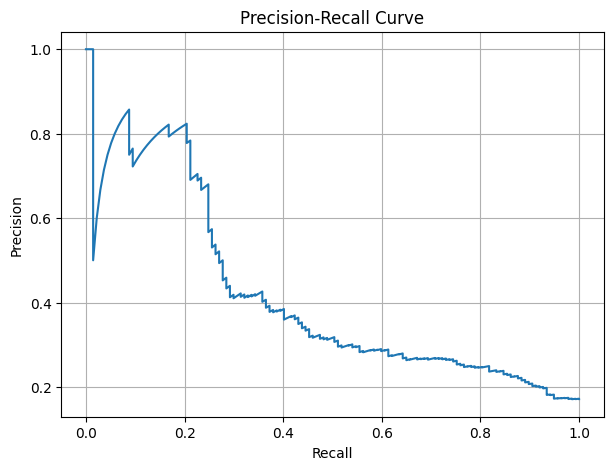

In [27]:
plt.figure(figsize=(7,5))

plt.plot(recall, precision)

plt.xlabel("Recall")
plt.ylabel("Precision")

plt.title("Precision-Recall Curve")

plt.grid()

plt.savefig(
    RESULTS_DIR / "pr_curve_voting.png"
)

plt.show()

In [28]:
f1_scores = []

for p, r in zip(precision[:-1], recall[:-1]):

    f1 = (2 * p * r) / (p + r + 1e-10)

    f1_scores.append(f1)

best_index = np.argmax(f1_scores)

best_threshold = thresholds[best_index]

print("Best Threshold:", best_threshold)

Best Threshold: 0.4472933398000316


In [29]:
sample_size = min(500, len(X_val))

random_indices = np.random.choice(
    len(X_val),
    sample_size,
    replace=False
)

X_shap = X_val[random_indices]

In [30]:
explainer = shap.TreeExplainer(best_xgb)

shap_values = explainer.shap_values(X_shap)

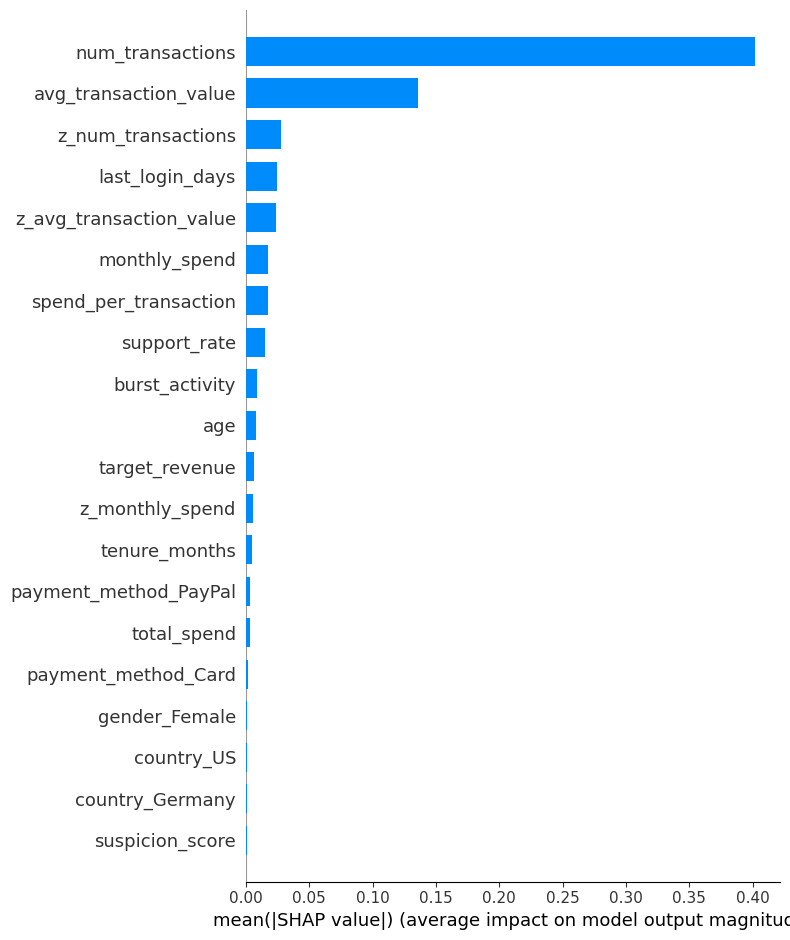

In [31]:
shap.summary_plot(
    shap_values,
    X_shap,
    feature_names=feature_columns,
    plot_type='bar',
    show=False
)

plt.savefig(
    SHAP_DIR / "global_feature_importance.png",
    bbox_inches='tight'
)

plt.show()

In [32]:
voting_pred = (
    voting_val_prob >= best_threshold
).astype(int)

false_negative_indices = np.where(
    (y_val == 1) & (voting_pred == 0)
)[0]

print(false_negative_indices[:5])

[ 2  6  7 10 16]


In [33]:
for idx in false_negative_indices[:3]:

    shap.force_plot(
        explainer.expected_value,
        explainer.shap_values(X_val[idx:idx+1])[0],
        X_val[idx:idx+1],
        matplotlib=True,
        show=False
    )

    plt.savefig(
        SHAP_DIR / f"false_negative_{idx}.png",
        bbox_inches='tight'
    )

    plt.close()

In [34]:
final_bundle = {
    "model": voting_clf,
    "threshold": best_threshold
}

joblib.dump(
    final_bundle,
    RESULTS_DIR / "fraud_model.pkl"
)

['results\\fraud_model.pkl']